## Day 17: Evals & LangSmith

Today you learn how to measure, trace, and improve your AI apps systematically. Without evals, you're guessing. With evals, you're engineering.

#### 1. Why Evals Matter

Without evals:
  "My chatbot seems pretty good" 🤷
  You change a prompt → did it improve? No idea.
  User complains → which part failed? No idea.

With evals:
  "My RAG system scores 8.2/10 on answer accuracy"
  You change chunk size → score goes 8.2 → 8.7 ✅
  User complains → trace shows retrieval returned wrong chunks ✅

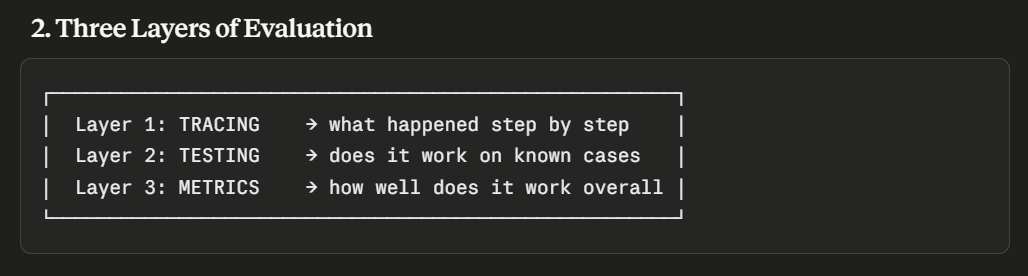

#### 3. Setup LangSmith (Free Tier)

1. Go to smith.langchain.com
2. Sign up for free account
3. Create a project called "langchain-course"
4. Go to Settings → API Keys → Create key
5. Copy the key

In [1]:
# Cell 1: Setup and verify LangSmith
from dotenv import load_dotenv
import os

load_dotenv()

# Verify env vars
required = [
    "LANGCHAIN_TRACING_V2",
    "LANGCHAIN_API_KEY",
    "LANGCHAIN_PROJECT"
]

print("LangSmith Configuration:")
for var in required:
    val = os.getenv(var)
    status = "✅" if val else "❌ MISSING"
    display = val[:20] + "..." if val and len(val) > 20 else val
    print(f"  {var}: {status} {display or ''}")

LangSmith Configuration:
  LANGCHAIN_TRACING_V2: ✅ true
  LANGCHAIN_API_KEY: ✅ lsv2_pt_e43d40b61ffc...
  LANGCHAIN_PROJECT: ✅ langchain-learnings


In [2]:
# Cell 2: Core imports
from langchain_groq import ChatGroq
from langchain_ollama import OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langsmith import Client
from langsmith.evaluation import evaluate
from langsmith.schemas import Run, Example
import json, os, time
from typing import Dict, List, Any, Optional
from dotenv import load_dotenv

load_dotenv()

llm    = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
fast   = ChatGroq(model="llama-3.1-8b-instant",    temperature=0)
client = Client()

print("✅ LangSmith client ready")
print(f"   Project: {os.getenv('LANGCHAIN_PROJECT')}")

d:\AI\Langchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ LangSmith client ready
   Project: langchain-learnings


In [3]:
# Cell 3: Automatic tracing - just run your chain normally
# LangSmith traces EVERY chain call automatically
# when LANGCHAIN_TRACING_V2=true

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# This chain is automatically traced
chain = (
    ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant. Answer concisely."),
        ("human", "{question}")
    ])
    | llm
    | StrOutputParser()
)

# Run it - check LangSmith dashboard after this!
result = chain.invoke({"question": "What is LangGraph?"})
print("Chain result:", result[:200])
print("\n✅ Check smith.langchain.com → your project → you'll see this trace!")

Chain result: LangGraph is an AI model developed by Meta, designed to process and generate human-like language. It's a large language model that can understand and respond to natural language inputs.

✅ Check smith.langchain.com → your project → you'll see this trace!


In [4]:
# Cell 4: Manual tracing with custom metadata
from langsmith import traceable

@traceable(
    name="rag_qa_pipeline",        # name shown in LangSmith
    tags=["rag", "production"],    # filter by tags
    metadata={"version": "1.0"}    # custom metadata
)
def rag_qa(question: str, context: str) -> str:
    """RAG Q&A function — traced automatically"""
    response = llm.invoke([
        SystemMessage(content=f"""Answer based ONLY on this context:
{context}

If answer not in context, say 'I don't know'."""),
        HumanMessage(content=question)
    ])
    return response.content


# Test it
context = """
LangGraph is a library for building stateful multi-agent applications.
It uses a graph-based approach with nodes and edges.
It was released in 2024 by the LangChain team.
It supports human-in-the-loop workflows.
"""

result = rag_qa(
    "When was LangGraph released?",
    context
)
print(f"Answer: {result}")
print("\n✅ Check LangSmith → 'rag_qa_pipeline' trace with tags")

Answer: LangGraph was released in 2024.

✅ Check LangSmith → 'rag_qa_pipeline' trace with tags


In [5]:
# Cell 5: Nested tracing - trace sub-steps
from langsmith import traceable

@traceable(name="retrieve_docs")
def retrieve(query: str) -> List[str]:
    """Simulate document retrieval"""
    time.sleep(0.1)  # simulate latency
    return [
        f"Doc about {query}: LangGraph supports {query} features...",
        f"Reference: {query} is implemented using StateGraph..."
    ]


@traceable(name="generate_answer")
def generate(question: str, docs: List[str]) -> str:
    """Generate answer from retrieved docs"""
    context = "\n".join(docs)
    return rag_qa(question, context)


@traceable(name="full_rag_pipeline", tags=["rag", "nested"])
def full_rag(question: str) -> Dict:
    """Full RAG pipeline with nested traces"""
    # Each nested function shows as sub-span in LangSmith
    docs   = retrieve(question)
    answer = generate(question, docs)

    return {
        "question": question,
        "answer":   answer,
        "sources":  len(docs)
    }


result = full_rag("What is human-in-the-loop in LangGraph?")
print(f"Result: {result}")
print("\n✅ Check LangSmith → see nested spans: full_rag → retrieve + generate")

Result: {'question': 'What is human-in-the-loop in LangGraph?', 'answer': 'The context doesn\'t provide a direct definition of "human-in-the-loop in LangGraph". It only mentions that LangGraph supports this feature and that it is implemented using StateGraph.', 'sources': 2}

✅ Check LangSmith → see nested spans: full_rag → retrieve + generate


#### Layer 2 — Dataset-Based Testing

In [6]:
# Cell 6: Create evaluation dataset in LangSmith

# Define your ground truth test cases
qa_dataset = [
    {
        "question": "What is LangChain?",
        "answer":   "LangChain is an open-source framework for building LLM-powered applications."
    },
    {
        "question": "What does LCEL stand for?",
        "answer":   "LangChain Expression Language — it uses the pipe operator to compose chains."
    },
    {
        "question": "What is the difference between ChromaDB and FAISS?",
        "answer":   "ChromaDB persists to disk and supports metadata filtering. FAISS is faster but in-memory."
    },
    {
        "question": "What temperature should you use for RAG?",
        "answer":   "Temperature 0 for consistent, factual answers in RAG pipelines."
    },
    {
        "question": "What is a ReAct agent?",
        "answer":   "ReAct stands for Reason and Act. The agent thinks, takes an action, observes the result, then repeats."
    },
    {
        "question": "What is human-in-the-loop?",
        "answer":   "A pattern where the graph pauses execution and waits for human approval before continuing."
    },
]

# Create or load dataset in LangSmith
dataset_name = "langchain-course-qa-v1"

try:
    dataset = client.read_dataset(dataset_name=dataset_name)
    print(f"✅ Dataset loaded: {dataset_name}")
except Exception:
    dataset = client.create_dataset(
        dataset_name=dataset_name,
        description="LangChain course Q&A evaluation dataset"
    )

    # Add examples to dataset
    client.create_examples(
        inputs=  [{"question": d["question"]} for d in qa_dataset],
        outputs= [{"answer":   d["answer"]}   for d in qa_dataset],
        dataset_id=dataset.id
    )
    print(f"✅ Dataset created: {dataset_name}")
    print(f"   Examples: {len(qa_dataset)}")

✅ Dataset created: langchain-course-qa-v1
   Examples: 6


In [7]:
# Cell 7: Define the system under test
def qa_system(inputs: Dict) -> Dict:
    """
    The function being evaluated.
    Must accept a dict and return a dict.
    """
    question = inputs["question"]

    response = chain.invoke({"question": question})

    return {"answer": response}


# Quick test
test_result = qa_system({"question": "What is LangChain?"})
print(f"Test output: {test_result}")

Test output: {'answer': 'LangChain is an open-source framework for building applications with large language models (LLMs). It provides tools and infrastructure to develop, deploy, and manage LLM-based projects, focusing on ease of use, flexibility, and scalability.'}


#### Layer 3 — Evaluators (Metrics)

In [8]:
# Cell 8: LLM-as-judge evaluators

def correctness_evaluator(run: Run, example: Example) -> Dict:
    """
    Evaluator 1: Is the answer factually correct?
    Uses LLM to judge against ground truth.
    """
    question       = example.inputs.get("question", "")
    expected       = example.outputs.get("answer", "")
    predicted      = run.outputs.get("answer", "")

    judge_response = fast.invoke([
        SystemMessage(content="""You are an evaluator judging answer quality.
Score the predicted answer vs the expected answer.

Return JSON only:
{
  "score": 0.0-1.0,
  "reasoning": "brief explanation"
}

Scoring guide:
  1.0 = completely correct and complete
  0.7 = mostly correct, minor gaps
  0.5 = partially correct
  0.2 = mostly wrong
  0.0 = completely wrong"""),
        HumanMessage(content=f"""Question: {question}
Expected: {expected}
Predicted: {predicted}""")
    ])

    try:
        data = json.loads(judge_response.content.strip())
        return {
            "key":      "correctness",
            "score":    float(data.get("score", 0)),
            "comment":  data.get("reasoning", "")
        }
    except Exception:
        return {"key": "correctness", "score": 0.5, "comment": "Parse error"}


def conciseness_evaluator(run: Run, example: Example) -> Dict:
    """
    Evaluator 2: Is the answer concise?
    Penalizes unnecessarily verbose answers.
    """
    answer    = run.outputs.get("answer", "")
    words     = len(answer.split())

    if words <= 30:
        score, comment = 1.0, f"Concise ({words} words)"
    elif words <= 60:
        score, comment = 0.8, f"Acceptable length ({words} words)"
    elif words <= 100:
        score, comment = 0.6, f"Slightly verbose ({words} words)"
    else:
        score, comment = 0.3, f"Too verbose ({words} words)"

    return {"key": "conciseness", "score": score, "comment": comment}


def hallucination_evaluator(run: Run, example: Example) -> Dict:
    """
    Evaluator 3: Does the answer contain hallucinations?
    Checks for confident claims not in expected answer.
    """
    expected  = example.outputs.get("answer", "")
    predicted = run.outputs.get("answer", "")

    judge = fast.invoke([
        SystemMessage(content="""Check if the predicted answer contains
any false information or hallucinations not supported by the expected answer.

Return JSON only:
{"hallucination_detected": true/false, "confidence": 0.0-1.0}"""),
        HumanMessage(content=f"""Expected: {expected}
Predicted: {predicted}""")
    ])

    try:
        data  = json.loads(judge.content.strip())
        hallu = data.get("hallucination_detected", False)
        return {
            "key":     "no_hallucination",
            "score":   0.0 if hallu else 1.0,
            "comment": "Hallucination detected" if hallu else "No hallucination"
        }
    except Exception:
        return {"key": "no_hallucination", "score": 0.5, "comment": "Parse error"}


print("✅ Three evaluators defined:")
print("   - correctness_evaluator   (LLM judge)")
print("   - conciseness_evaluator   (word count)")
print("   - hallucination_evaluator (LLM judge)")

✅ Three evaluators defined:
   - correctness_evaluator   (LLM judge)
   - conciseness_evaluator   (word count)
   - hallucination_evaluator (LLM judge)


In [9]:
# Cell 9: Run evaluation suite

print("Running evaluation suite...")
print("This will appear in LangSmith under Evaluations\n")

results = evaluate(
    qa_system,                          # function to evaluate
    data=dataset_name,                  # dataset to test against
    evaluators=[
        correctness_evaluator,
        conciseness_evaluator,
        hallucination_evaluator
    ],
    experiment_prefix="baseline",       # shown in LangSmith
    metadata={
        "model":    "llama-3.3-70b-versatile",
        "version":  "1.0",
        "day":      "day17"
    }
)

print("\n✅ Evaluation complete!")
print("   Check smith.langchain.com → Evaluations tab")

Running evaluation suite...
This will appear in LangSmith under Evaluations

View the evaluation results for experiment: 'baseline-6121c324' at:
https://smith.langchain.com/o/299bdb8f-1268-4166-a459-24069c332a62/datasets/e58575ba-809f-4073-85eb-c515b8eb3b03/compare?selectedSessions=3ae34f6a-6843-45c5-b620-5de9aa70599d




6it [00:08,  1.38s/it]


✅ Evaluation complete!
   Check smith.langchain.com → Evaluations tab


In [10]:
# Cell 10: Parse and display results locally
results_list = list(results)

scores = {
    "correctness":      [],
    "conciseness":      [],
    "no_hallucination": []
}

for r in results_list:
    for eval_result in r.get("evaluation_results", {}).get("results", []):
        key   = eval_result.key
        score = eval_result.score
        if key in scores and score is not None:
            scores[key].append(score)

print("\n📊 Evaluation Results Summary")
print("="*50)
for metric, vals in scores.items():
    if vals:
        avg = sum(vals) / len(vals)
        bar = "█" * int(avg * 20)
        print(f"\n{metric}:")
        print(f"  Score: {avg:.2f}/1.0  {bar}")
        print(f"  Min: {min(vals):.2f} | Max: {max(vals):.2f} | N={len(vals)}")


📊 Evaluation Results Summary

correctness:
  Score: 0.37/1.0  ███████
  Min: 0.00 | Max: 0.90 | N=6

conciseness:
  Score: 0.87/1.0  █████████████████
  Min: 0.60 | Max: 1.00 | N=6

no_hallucination:
  Score: 0.33/1.0  ██████
  Min: 0.00 | Max: 1.00 | N=6


In [11]:
# Cell 11: Compare two prompts systematically

# Version A: basic prompt
def qa_system_v1(inputs: Dict) -> Dict:
    chain_v1 = (
        ChatPromptTemplate.from_messages([
            ("system", "Answer the question."),
            ("human",  "{question}")
        ])
        | llm | StrOutputParser()
    )
    return {"answer": chain_v1.invoke({"question": inputs["question"]})}


# Version B: engineered prompt
def qa_system_v2(inputs: Dict) -> Dict:
    chain_v2 = (
        ChatPromptTemplate.from_messages([
            ("system", """You are a precise technical assistant.
Rules:
- Answer in 1-2 sentences maximum
- Be technically accurate
- No filler phrases like 'Great question!'
- If uncertain, say so"""),
            ("human", "{question}")
        ])
        | llm | StrOutputParser()
    )
    return {"answer": chain_v2.invoke({"question": inputs["question"]})}


# Run both experiments
print("Running experiment A: Basic prompt")
results_v1 = evaluate(
    qa_system_v1,
    data=dataset_name,
    evaluators=[correctness_evaluator, conciseness_evaluator],
    experiment_prefix="v1_basic_prompt"
)

print("\nRunning experiment B: Engineered prompt")
results_v2 = evaluate(
    qa_system_v2,
    data=dataset_name,
    evaluators=[correctness_evaluator, conciseness_evaluator],
    experiment_prefix="v2_engineered_prompt"
)

print("\n✅ Both experiments complete!")
print("   Compare them in LangSmith → Evaluations → select both → Compare")

Running experiment A: Basic prompt
View the evaluation results for experiment: 'v1_basic_prompt-ed987d5a' at:
https://smith.langchain.com/o/299bdb8f-1268-4166-a459-24069c332a62/datasets/e58575ba-809f-4073-85eb-c515b8eb3b03/compare?selectedSessions=1bacbdaf-25fa-4e42-941f-0daec5420d9f




6it [00:09,  1.64s/it]



Running experiment B: Engineered prompt
View the evaluation results for experiment: 'v2_engineered_prompt-87452036' at:
https://smith.langchain.com/o/299bdb8f-1268-4166-a459-24069c332a62/datasets/e58575ba-809f-4073-85eb-c515b8eb3b03/compare?selectedSessions=bfbdd161-16c8-4e7c-bbaa-0e1b277b13a8




6it [00:04,  1.26it/s]


✅ Both experiments complete!
   Compare them in LangSmith → Evaluations → select both → Compare


In [ ]:
# Cell 12 (revised): RAG eval with HuggingFace embeddings
import os
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings

def get_hf_embeddings(model_name: str = "BAAI/bge-base-en-v1.5"):
    """
    Free, open-source embeddings via HuggingFace.
    Downloads model once, runs locally on your RTX 5060.
    No API key needed.
    """
    return HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs={
            "device": "cuda"    # uses your RTX 5060 ← faster than CPU
        },
        encode_kwargs={
            "normalize_embeddings": True    # important for BGE models
        }
    )


def build_test_rag():
    """Build RAG with HuggingFace embeddings"""
    from langchain_community.document_loaders import TextLoader
    import shutil

    content = """
LangChain Overview:
LangChain was created by Harrison Chase and released in 2022.
It supports Python and JavaScript.
The core components are: Models, Prompts, Chains, Memory, Agents.

LangGraph Overview:
LangGraph was built on top of LangChain and released in 2024.
It uses StateGraph for defining workflows.
It supports human-in-the-loop patterns using interrupt().

LangSmith Overview:
LangSmith is the observability platform for LangChain.
Free tier includes 5,000 traces per month.
It supports dataset creation and LLM-as-judge evaluation.
"""

    os.makedirs("eval_docs", exist_ok=True)
    with open("eval_docs/test_kb.txt", "w") as f:
        f.write(content)

    loader   = TextLoader("eval_docs/test_kb.txt")
    docs     = loader.load()
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=200, chunk_overlap=30
    )
    chunks = splitter.split_documents(docs)

    if os.path.exists("./eval_chroma"):
        shutil.rmtree("./eval_chroma")

    # ← Only this line changed
    hf_embeddings = get_hf_embeddings("BAAI/bge-base-en-v1.5")

    vs = Chroma.from_documents(
        chunks,
        hf_embeddings,              # ← HuggingFace instead of Ollama
        persist_directory="./eval_chroma"
    )
    return vs.as_retriever(search_kwargs={"k": 2})


retriever = build_test_rag()
print("✅ Test RAG built with BAAI/bge-base-en-v1.5")

NameError: name 'RecursiveCharacterTextSplitter' is not defined